In [1]:
# PyTorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim import Adam
from torch.utils.data import random_split
import torchvision

# Additional Imports
import snntorch as snn
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# Dataset
import tonic
import tonic.datasets as datasets
import tonic.transforms as transforms
from torch.utils.data import DataLoader
from tonic import DiskCachedDataset

# Network
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import spikeplot as splt
from snntorch import utils

# Set the seed for reproducibility of results
torch.manual_seed(0)

In [2]:
dataset = tonic.datasets.DVSGesture(save_to='./data', train=True)
events, target = dataset[0]
print(events)

  0%|          | 0/2443675558 [00:00<?, ?it/s]

KeyboardInterrupt: 

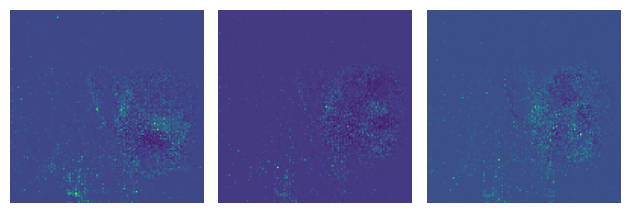

In [5]:
tonic.utils.plot_event_grid(events)

In [6]:
config = {
    # SNN Thresholds and Parameters
    "threshold1": 2.5,
    "threshold2": 8.0,
    "threshold3": 4.0,
    "threshold4": 2.0,
    "beta": 0.5,
    "num_steps": 10,
    
    # SNN Dense Shape
    "dense1_input": 32768,  # Adjusted based on input shape (2 * 128 * 128)
    "num_classes": 11,  # Adjusted for DVS Gesture dataset
    
    # Network
    "batch_norm": True,
    "dropout": 0.2,

    # Hyper Parameters
    "lr": 0.001,

    # Early Stopping
    "min_delta": 1e-6,
    "patience_es": 20,

    # Training
    "epochs": 1
}


In [7]:
import torch
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as torchvision_transforms
import tonic
import tonic.transforms as transforms

# Define sensor size for DVS128 Gesture dataset
sensor_size = tonic.datasets.DVSGesture.sensor_size

# Define transformations
# Note: The use of torch.from_numpy is removed as Tonic's transforms handle conversion.
downsample_factor = 2  # Factor by which to downsample the input
transform = tonic.transforms.Compose([
    transforms.Denoise(filter_time=10000),
    transforms.ToFrame(sensor_size=sensor_size, time_window=10000),
    # You can add other transformations specific to your application, such as random rotations
])

# Load DVS128 Gesture datasets without caching
trainset = tonic.datasets.DVSGesture(save_to='./tmp/data', transform=transform, train=True)
testset = tonic.datasets.DVSGesture(save_to='./tmp/data', transform=transform, train=False)

# Split trainset into training and validation datasets
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

# Create DataLoaders for training, validation, and testing
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=tonic.collation.PadTensors(batch_first=False))
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=tonic.collation.PadTensors(batch_first=False))
test_loader = DataLoader(testset, batch_size=batch_size, collate_fn=tonic.collation.PadTensors(batch_first=False))

# Fetch a single batch from the train_loader to inspect the shape
data, targets = next(iter(train_loader))
print(f"Data shape: {data.shape}")  # Example output: torch.Size([batch_size, timesteps, channels, height, width])
print(f"Targets shape: {targets.shape}")  # Example output: torch.Size([batch_size])


  0%|          | 0/2443675558 [00:00<?, ?it/s]

Extracting ./tmp/data/DVSGesture/ibmGestureTrain.tar.gz to ./tmp/data/DVSGesture


  0%|          | 0/691455012 [00:00<?, ?it/s]

Extracting ./tmp/data/DVSGesture/ibmGestureTest.tar.gz to ./tmp/data/DVSGesture
Data shape: torch.Size([960, 16, 2, 128, 128])
Targets shape: torch.Size([16])


In [8]:
import torch
import torch.nn as nn
import snntorch as snn

class SNN(nn.Module):
    def __init__(self, config):
        super(SNN, self).__init__()

        # Initialize configuration parameters
        self.thresh1 = config["threshold1"]
        self.thresh2 = config["threshold2"]
        self.thresh3 = config["threshold3"]
        self.thresh4 = config["threshold4"]
        self.thresh5 = config.get("threshold5", 2.0)  # Add threshold for the new layer
        self.beta = config["beta"]
        self.num_steps = config["num_steps"]

        # Hyper Params for Layers
        self.batch_norm = config["batch_norm"]
        self.dropout_percent = config["dropout"]

        # Adjust dense1_input based on input shape: 2 * 128 * 128
        self.dense1_input = 2 * 128 * 128  # For input shape of (2, 128, 128)
        self.num_classes = 11  # Number of classes for DVS Gesture dataset

        # Network Layers
        self.fc1 = nn.Linear(self.dense1_input, self.dense1_input // 4)  # Adjust input size
        self.bn1 = nn.BatchNorm1d(self.dense1_input // 4)
        self.lif1 = snn.Leaky(beta=self.beta, threshold=self.thresh1)
        
        self.fc2 = nn.Linear(self.dense1_input // 4, self.dense1_input // 8)  # Adjust size
        self.bn2 = nn.BatchNorm1d(self.dense1_input // 8)
        self.lif2 = snn.Leaky(beta=self.beta, threshold=self.thresh2)
        
        self.fc3 = nn.Linear(self.dense1_input // 8, self.dense1_input // 16)  # Adjust size for additional layer
        self.bn3 = nn.BatchNorm1d(self.dense1_input // 16)
        self.lif3 = snn.Leaky(beta=self.beta, threshold=self.thresh3)
        
        self.fc4 = nn.Linear(self.dense1_input // 16, self.num_classes)  # Final output layer
        self.bn4 = nn.BatchNorm1d(self.num_classes)
        self.lif4 = snn.Leaky(beta=self.beta, threshold=self.thresh5)
        
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(self.dropout_percent)
        
    def forward(self, inpt):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        spike4_rec = []
        mem4_rec = []
        
        for step in range(inpt.shape[0]):  # Loop over timesteps
            current_input = inpt[step]  # Shape: [batch_size, channels, height, width]
            current_input = self.flatten(current_input)  # Flatten to [batch_size, 2 * 128 * 128]

            current1 = self.fc1(current_input)
            current1 = self.bn1(current1)
            spike1, mem1 = self.lif1(current1, mem1)

            current2 = self.fc2(spike1)
            current2 = self.bn2(current2)
            spike2, mem2 = self.lif2(current2, mem2)

            current3 = self.fc3(spike2)
            current3 = self.bn3(current3)
            spike3, mem3 = self.lif3(current3, mem3)

            current4 = self.fc4(spike3)
            current4 = self.bn4(current4)
            spike4, mem4 = self.lif4(current4, mem4)
            
            spike4_rec.append(spike4)
            mem4_rec.append(mem4)

        return torch.stack(spike4_rec, dim=0), torch.stack(mem4_rec, dim=0)


In [9]:
class EarlyStopping:
    def __init__(self, patience=config["patience_es"], min_delta=config["min_delta"]):
        # Early stops the training if validation loss doesn't improve after a given patience.
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            print(f"Earlystop {self.counter}/{self.patience}\n")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0

In [ ]:
# Model initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN(config).to(device)

# Optimizer and Loss Function
optimizer = Adam(model.parameters(), lr=config["lr"])
criterion = nn.CrossEntropyLoss()

# Early Stopping
early_stopping = EarlyStopping(patience=config["patience_es"], min_delta=config["min_delta"])

In [10]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for data, targets in train_loader:
        data, targets = data.to(device), targets.to(device)
        #print(data.shape)

        optimizer.zero_grad()
        spike_out, _ = model(data)
        output = spike_out.sum(dim=0)
        loss = criterion(output, targets)
        running_loss += loss.item()

        _, predicted_train = torch.max(output.data, 1)
        total_train += targets.size(0)
        correct_train += (predicted_train == targets).sum().item()
        
        print(f"Train Loss: {loss.item():.2f}")
        
        acc = SF.accuracy_rate(spike_out, targets) 
        print(f"Accuracy: {acc * 100:.2f}%\n")

        loss.backward()
        optimizer.step()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    return train_loss, train_accuracy

In [11]:
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device), targets.to(device)
            spike_out, _ = model(data)
            output = spike_out.sum(dim=0)
            loss = criterion(output, targets)
            val_loss += loss.item()

            _, predicted_val = torch.max(output.data, 1)
            total_val += targets.size(0)
            correct_val += (predicted_val == targets).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    return val_loss, val_accuracy

In [ ]:
from tqdm import tqdm

train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []
best_val_accuracy = 0
model_path = "best_SNN_model_dvs.pth"

for epoch in tqdm(range(config["epochs"]), desc="Epochs"):
    train_loss, train_accuracy = train(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    tqdm.write(f"Epoch: {epoch + 1}, Training Loss: {train_loss:.5f}, Training Accuracy: {train_accuracy:.2f}%, "
               f"Validation Loss: {val_loss:.5f}, Validation Accuracy: {val_accuracy:.2f}%\n")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), model_path)
        tqdm.write(f"Saved model with improved validation accuracy: {val_accuracy:.2f}% \n")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        tqdm.write("\nEarly stopping triggered")
        break

In [ ]:
# Plotting training, validation, and test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting training, validation, and test accuracies
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [ ]:
def test(model, test_loader, criterion, device, model_path="best_SNN_model_dvs.pth"):

    # Initialize variables for test loss and accuracy
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    # Restore best BSNN Model
    if os.path.isfile(model_path):
        model.load_state_dict(torch.load(model_path))
        print(f"Loaded saved model from {model_path}\n")

    # Switch model to evaluation mode
    model.eval()

    # Iterate over the test data
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            outputs, _ = model(data)  # Modify according to your model's output
            outputs = outputs.mean(dim=0)

            # Calculate loss
            loss = criterion(outputs, targets)
            test_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_test += targets.size(0)
            correct_test += (predicted == targets).sum().item()

    # Calculate average loss and accuracy
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct_test / total_test

    return test_loss, test_accuracy


In [ ]:
test_loss, test_accuracy = test(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")